In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

from sklearn.decomposition import PCA

import matplotlib.lines as mlines
from sklearn.cluster import KMeans
from collections import Counter

from scipy.stats import chi2_contingency

#für Hierarchisches Clustering
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

In [3]:
# Dataframe laden und vorbereiten
regions = ['CDR_H1', 'CDR_H2', 'CDR_H3', 'CDR_L1', 'CDR_L2', 'CDR_L3']
ab_ag_annotated = (
    pd.read_csv("data/ab_ag_annotated.tsv", sep="\t", usecols=["pdb"] + ["antigen_name"] + ["antigen_species"] + ["resolution"] + regions)
    .dropna(subset= regions)
    .drop_duplicates(subset = ["pdb"] + regions, keep="first")
    .reset_index(drop=True)
)

ab_ag_annotated = ab_ag_annotated[ab_ag_annotated['resolution'] <= 3.5]

#####liste mit den top antigen_names erstellen
top_antigens = ab_ag_annotated['antigen_name'].value_counts().head(10).index.tolist()
#dataframe filtern sodass nur top 10 antigene drin bleiben
ab_ag_annotated_top = ab_ag_annotated[ab_ag_annotated['antigen_name'].isin(top_antigens)].copy()
#antigen labels definieren sodass nur top 10
antigen_labels = ab_ag_annotated_top["antigen_name"].tolist() #entspricht der spalte "antigen_name" aus ab_ag_annotated_top (aber mit neuen indices!)

#überprüfung was die top 10 sind
print("Top 10 Antigene:")
for ant in top_antigens:
    print(f"-{ant}")

# Liste mit allen proteinogenen Aminosäuren (wird später für die PCA benötigt)
residues = ["A", "C", "D", "E", "F", "G", "H", "I", "K", "L", "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y"]

# Liste aller CDR-Regionen
regions = ["CDR_H1", "CDR_H2", "CDR_H3", "CDR_L1", "CDR_L2", "CDR_L3"]

Top 10 Antigene:
-spike glycoprotein
-spike protein s1
-guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 
-hemagglutinin
-envelope glycoprotein gp160
-envelope glycoprotein gp120
-neuraminidase
-surface glycoprotein
-hemagglutinin | hemagglutinin
-fusion glycoprotein f0


In [4]:
#PCA nur für AK mit antigen name in den top 10 (pca für alle ist zu finden in annasworksheet)

def residue_percentage(sequence, residues):
    """
    Berechnet den prozentualen Anteil jeder Aminosäure in der gegebenen Sequenz und gibt eine Liste seq_residues zurück,
    die jede Aminosäure als Tupel (residue, percentage) enthält.
    sequence: list, die eine CDR-Sequenz repäsentiert, und deren Einträge aus einem String pro Aminosäure besteht, z.B. ['A', 'R', 'N', ...]
    """
    seq_residues = []
    for residue in residues:
        percentage = sequence.count(residue) / len(sequence)
        seq_residues.append((residue, percentage))
    return seq_residues


def show_feature_space(feature_space, CDR_region, antigen_labels):#zusätzliches Argument für color-coding: antigen
    """
    Visualisiert den Feature-Space der CDR-Sequenzen mittels PCA in 3D.
    feature_space: pd.DataFrame, der die PDB-IDs in einer Spalte "pdb" und die prozentualen Anteile der Aminosäuren in den entsprechenden CDR-Sequenzen
    in je einer Spalte pro Aminosäure enthält.
    """
    X = feature_space.drop(columns=["pdb"])
    coords = PCA(n_components=2).fit_transform(X)
    
    #### Farbzuordnung vorbereiten
    unique_antigens = sorted(list(set(antigen_labels)))
    color_map = plt.get_cmap('gist_rainbow_r', len(unique_antigens))
    color_dict = {antigen: color_map(i) for i, antigen in enumerate(unique_antigens)}
    colors = [color_dict[a] for a in antigen_labels]
   

    # Plotten der PCA-Koordinaten in 2D
    fig, (ax_scatter, ax_legend) = plt.subplots(2,1,figsize=(10,10), gridspec_kw={'height_ratios': [4,1]})
    ax_scatter.scatter(coords[:, 0], coords[:, 1], c=colors, s=20, alpha=0.7)#zusätzliche Argumente für color-coding: c=color_codes, cmap='tab20', 
    ax_scatter.set_xlabel("PCA 1")
    ax_scatter.set_ylabel("PCA 2")
    ax_scatter.set_title(f"PCA of {CDR_region} Sequences")


    # 2. Legende als eigene Figure
    legend_fig, legend_ax = plt.subplots(figsize=(12, 12))  # Größe anpassen je nach Anzahl Antigene
    legend_ax.axis('off')  # Keine Achsen

    # Erstelle Handles
    handles = [mlines.Line2D([], [], color=color_dict[ant], marker='o', linestyle='None',
                             markersize=8, label=ant)
               for ant in unique_antigens]

    # Erzeuge Legende
    legend = legend_ax.legend(handles=handles, loc='center', ncol=1, fontsize='small')  # ncol=1 → alle untereinander

    legend_fig.tight_layout()
    plt.show()

In [5]:
'''Kann der Teil in die Funktion show_feature_space eingebaut werden?'''
unique_antigens = sorted(list(set(antigen_labels)))
color_map = plt.get_cmap('gist_rainbow_r', len(unique_antigens))
color_dict = {antigen: color_map(i) for i, antigen in enumerate(unique_antigens)}
colors = [color_dict[a] for a in antigen_labels]

# Dictionary, das die Feature-Space DataFrames für jede CDR-Region speichert
feature_spaces = {}
# Schleife über die CDR-Regionen, um den Feature-Space für jede CDR-Sequenz zu erstellen und zu visualisieren:
for region in regions: 
    # Berechne den prozentualen Anteil jeder Aminosäure in den CDR-Sequenzen und füge sie in den Feature-Space ein.
    fs_rows = [] #um daten vor befüllen des dataframes vorzubereiten damit es nicht so lange dauert
    for i, ab_ag_annotated_top_row in ab_ag_annotated_top.iterrows():
        pdb = ab_ag_annotated_top_row['pdb']
        antigen_name = ab_ag_annotated_top_row['antigen_name']
        antigen_species = ab_ag_annotated_top_row['antigen_species']
        seq_as_str = ab_ag_annotated_top_row[region]
        seq_as_list = list(seq_as_str)

        residues_percentages = residue_percentage(seq_as_list, residues)
        percentages = [pair[1] for pair in residues_percentages]

        seq_length = len(seq_as_list)

        fs_row = [pdb] + [antigen_name] + [antigen_species] + [seq_length] + percentages
        fs_rows.append(fs_row)

    feature_space = pd.DataFrame(fs_rows, columns=["pdb"] + ["antigen_name"] + ["antigen_species"] + ["seq_length"] + residues)
    columns_to_scale = ["seq_length"] + residues
    feature_space_z = feature_space.copy()
    feature_space_z[columns_to_scale] = scaler.fit_transform(feature_space[columns_to_scale])
    feature_spaces[region] = feature_space_z


In [6]:
feature_spaces["CDR_L1"]
any("M" in list(seq) for seq in ab_ag_annotated_top["CDR_L1"])


False

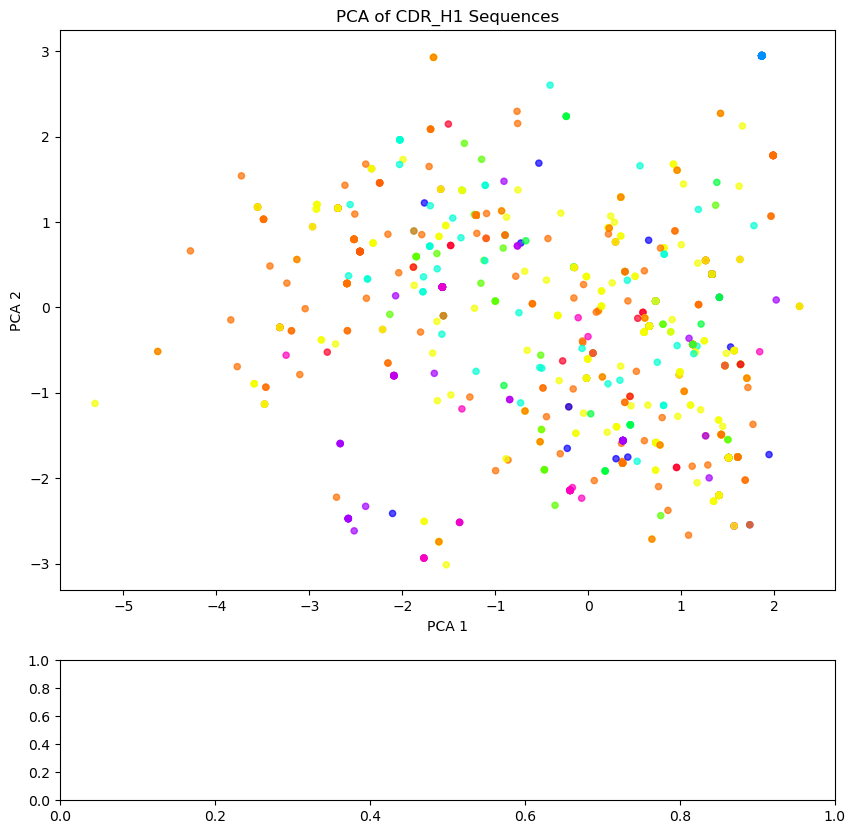

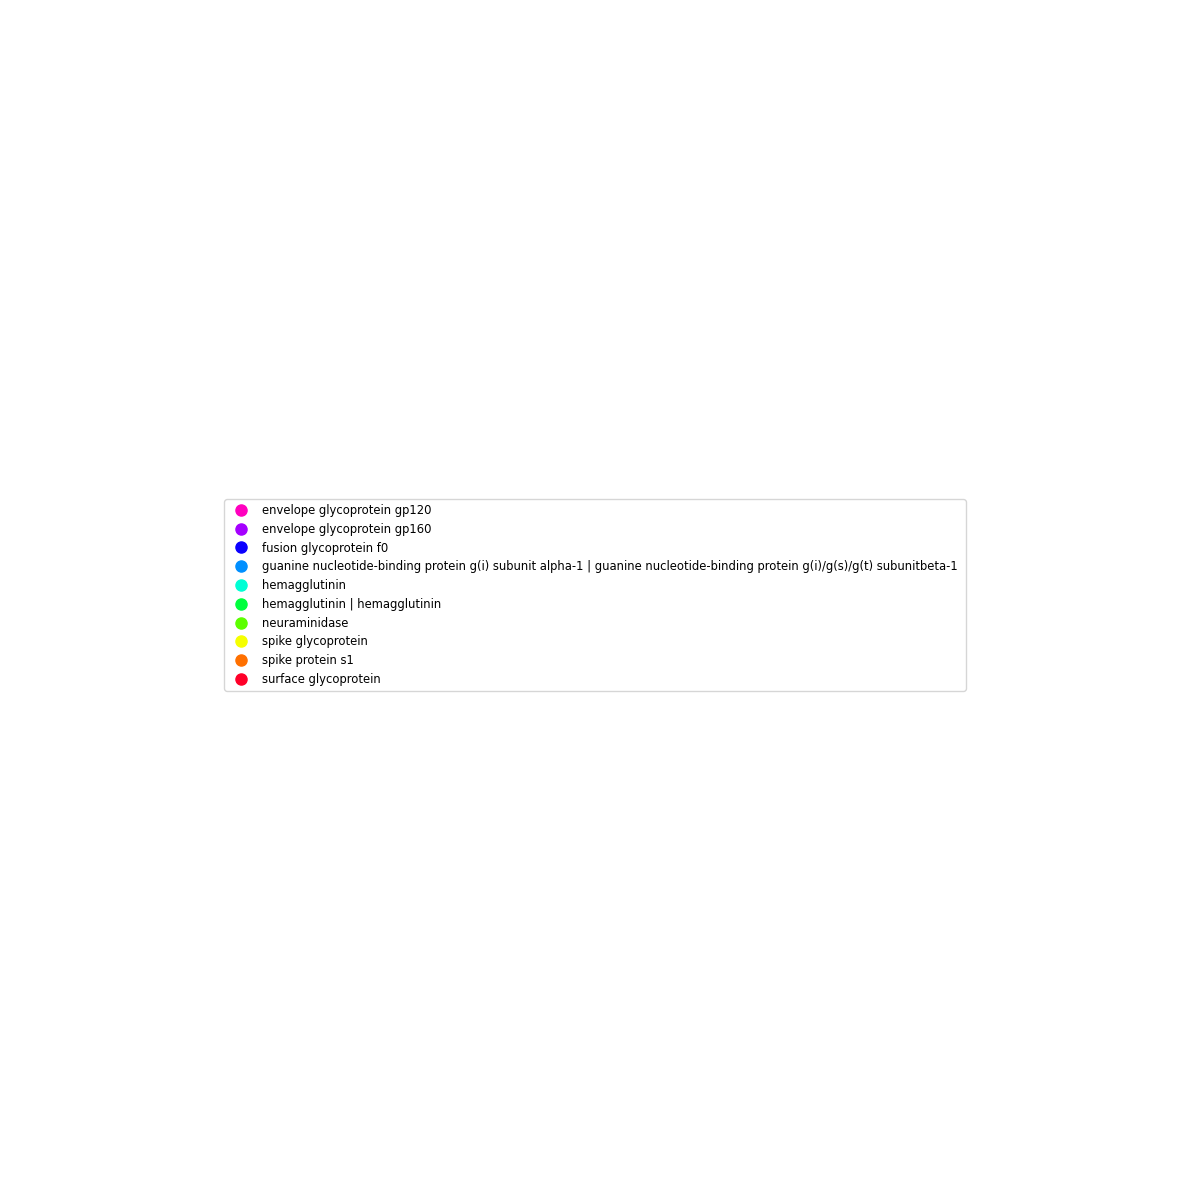

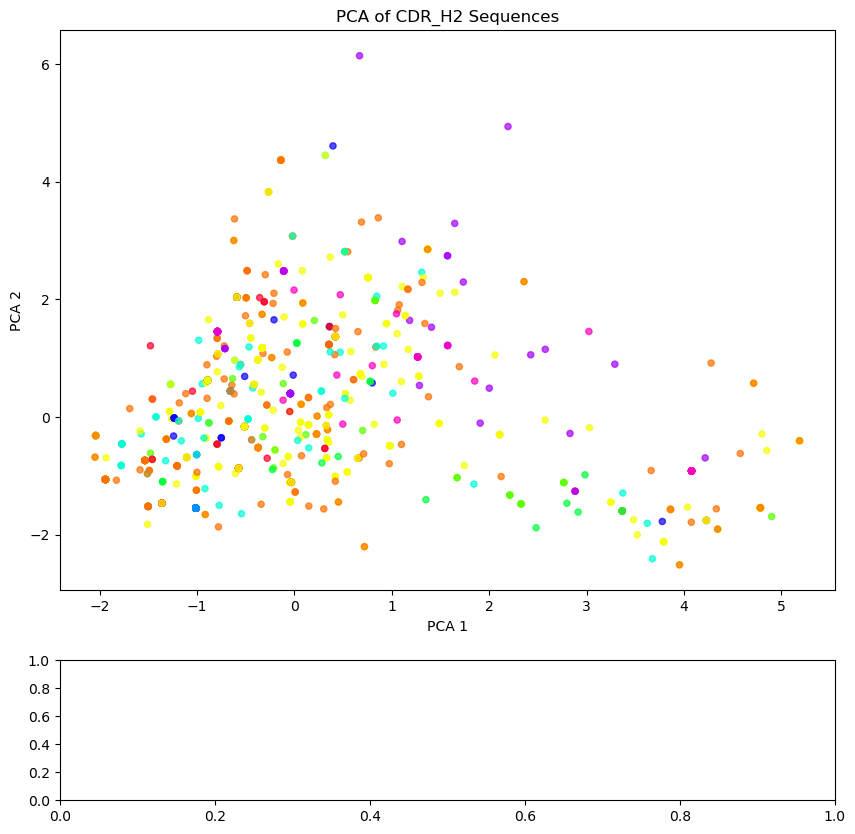

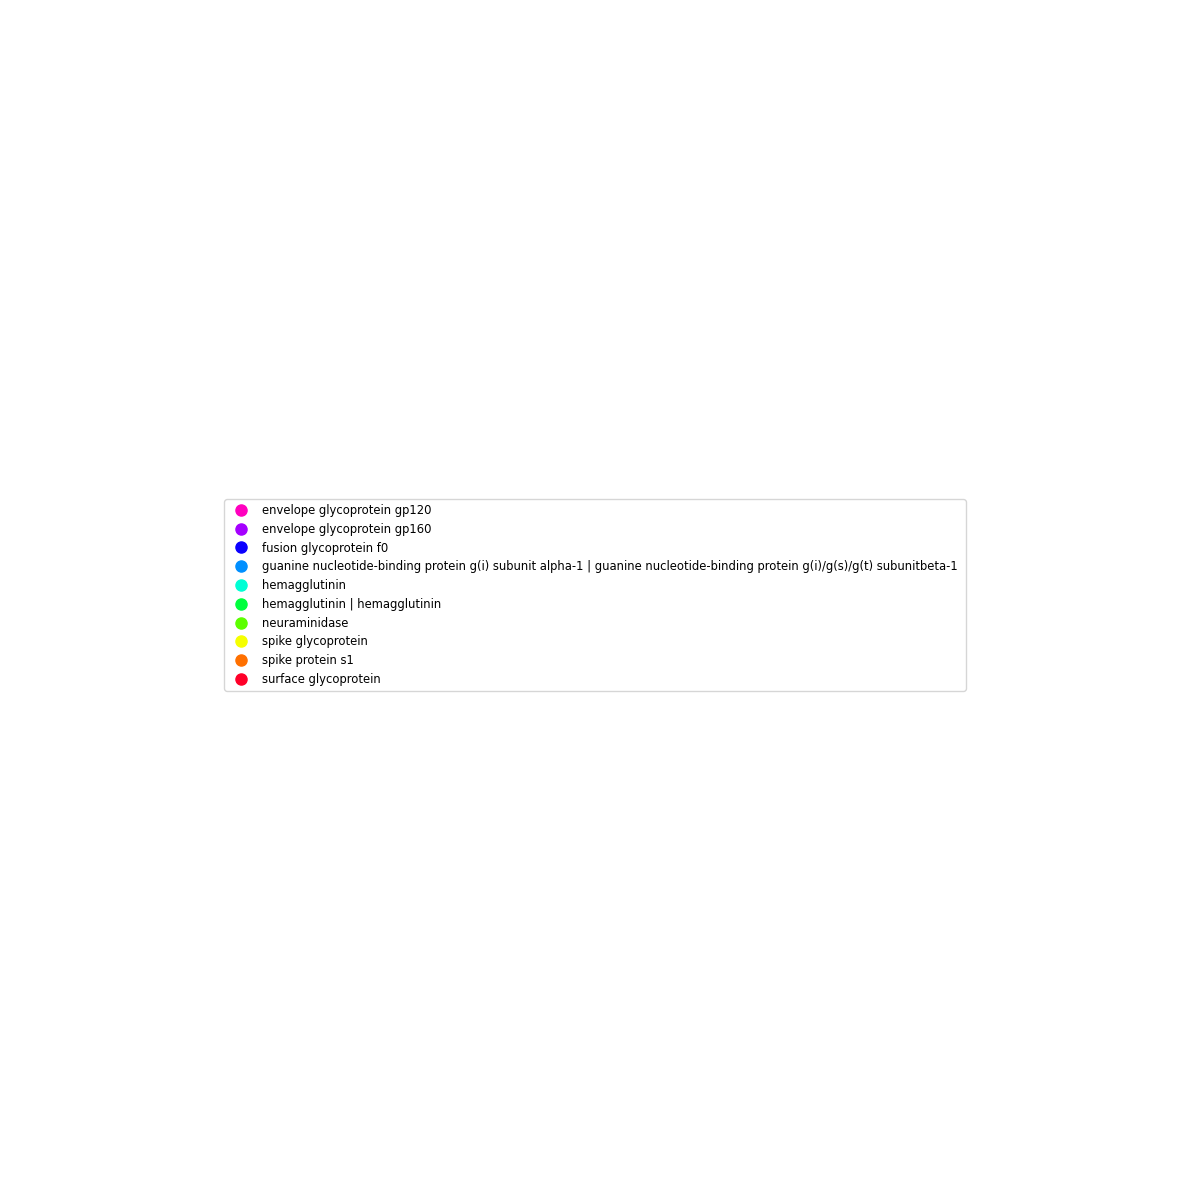

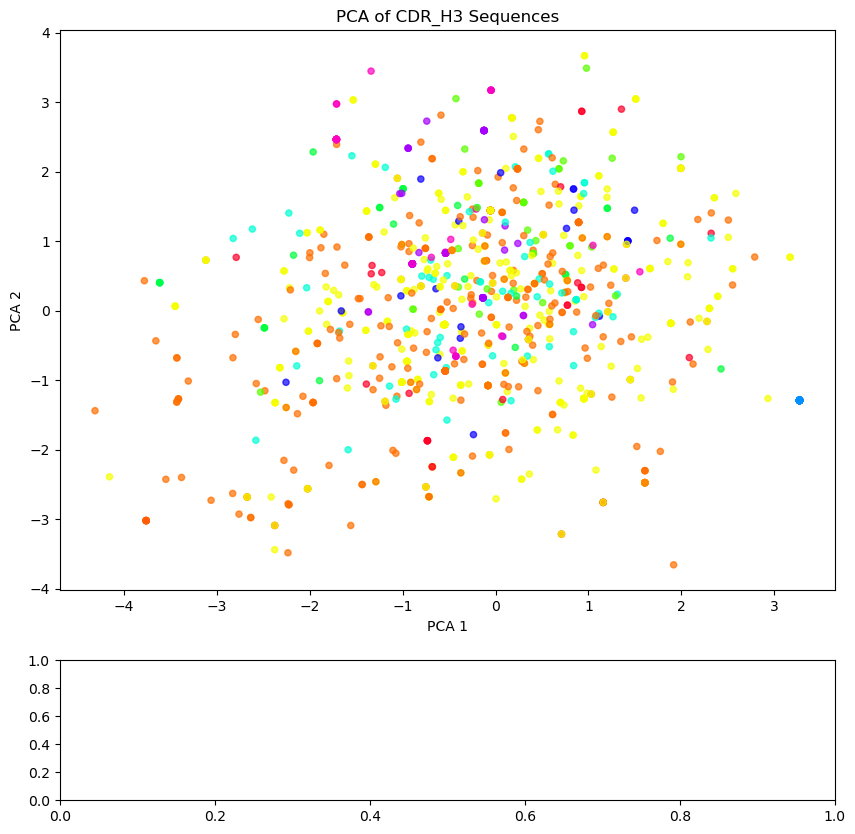

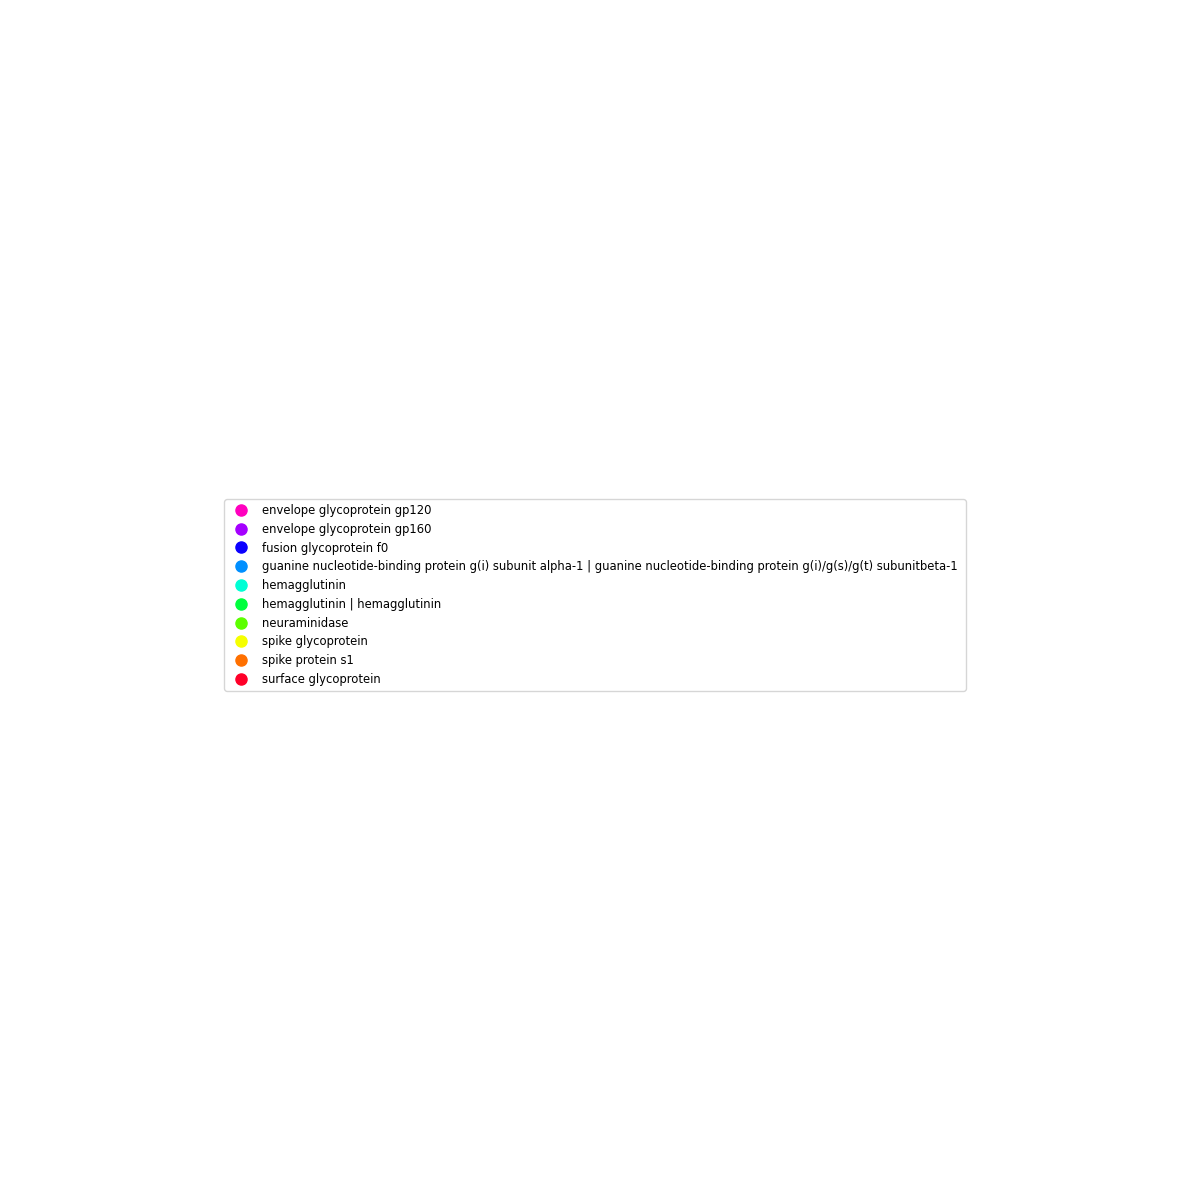

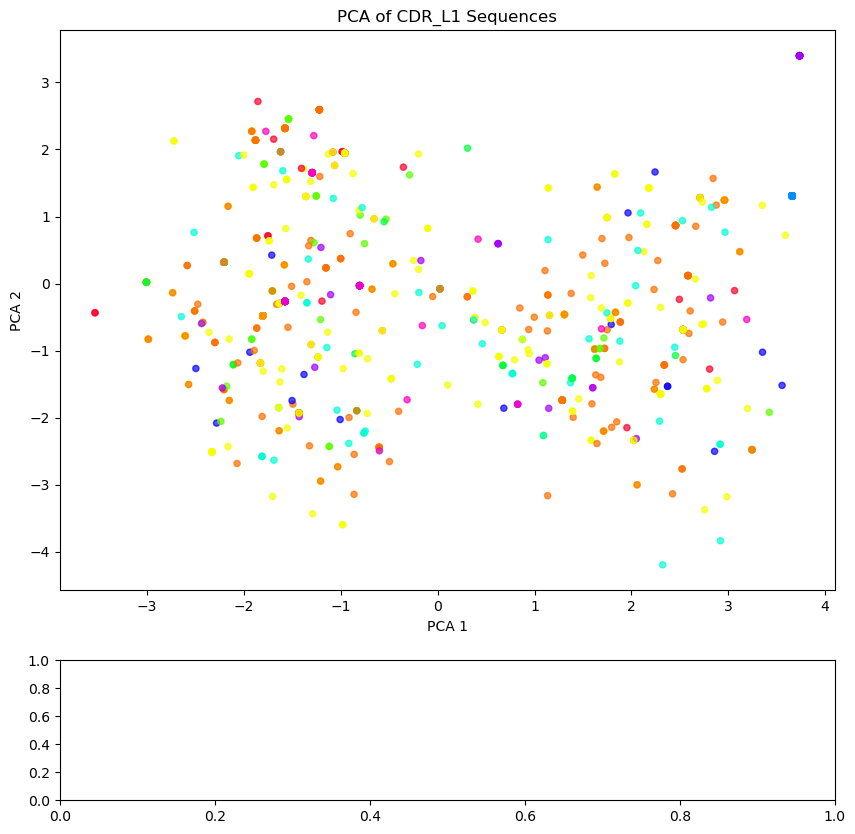

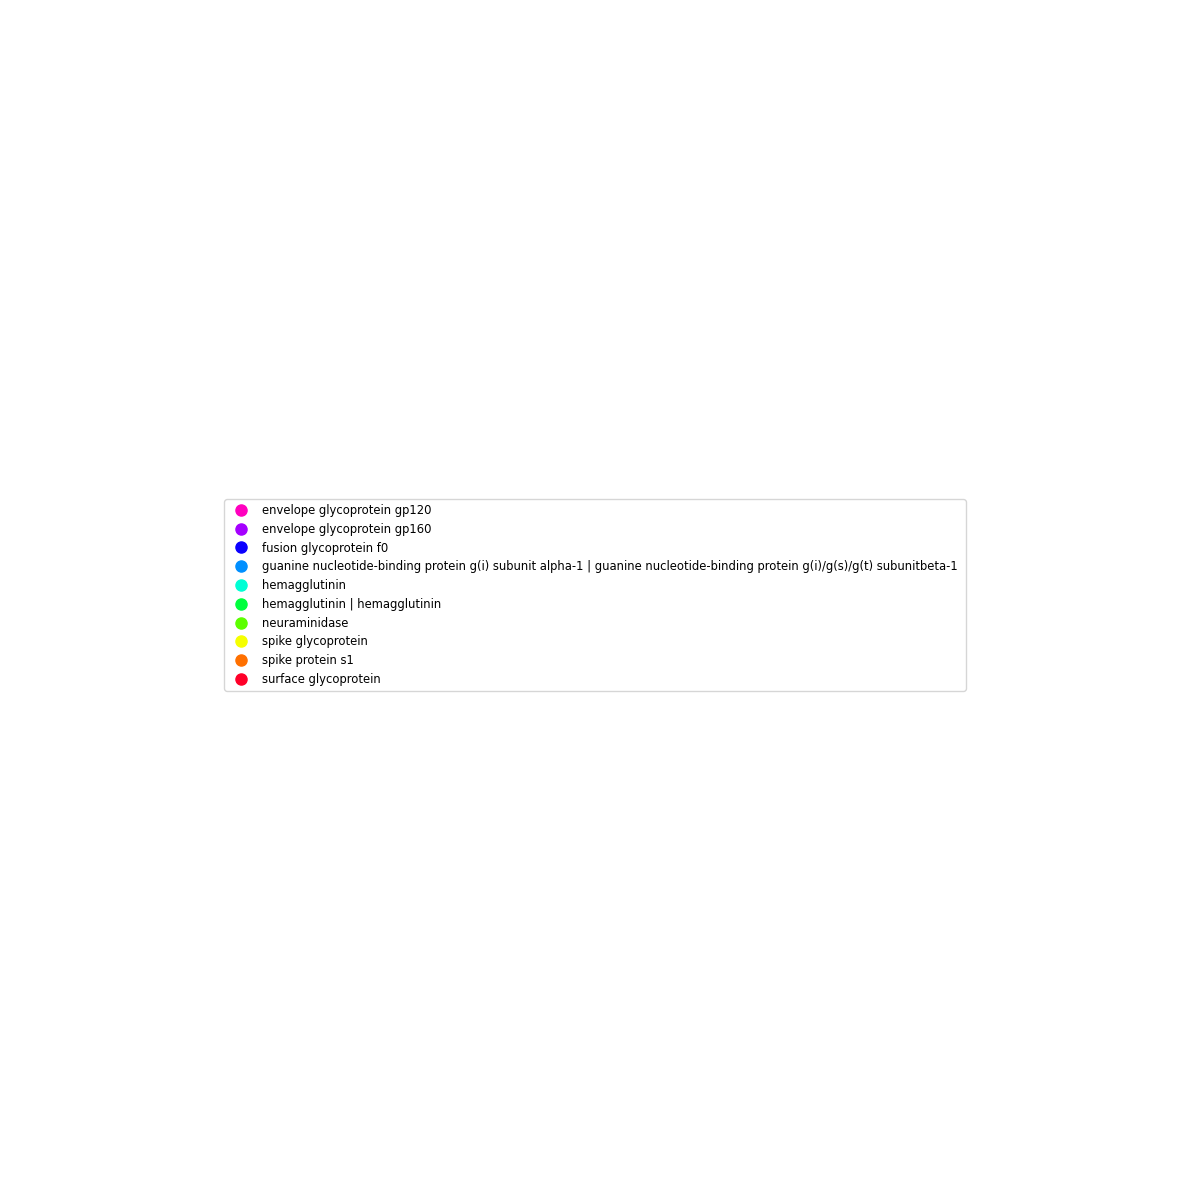

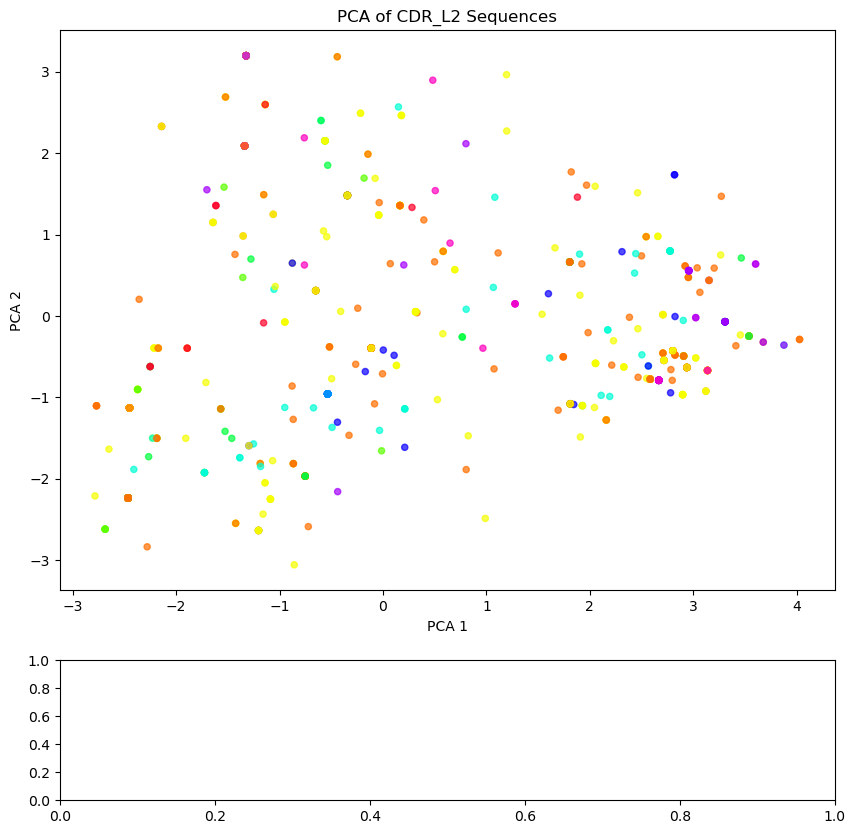

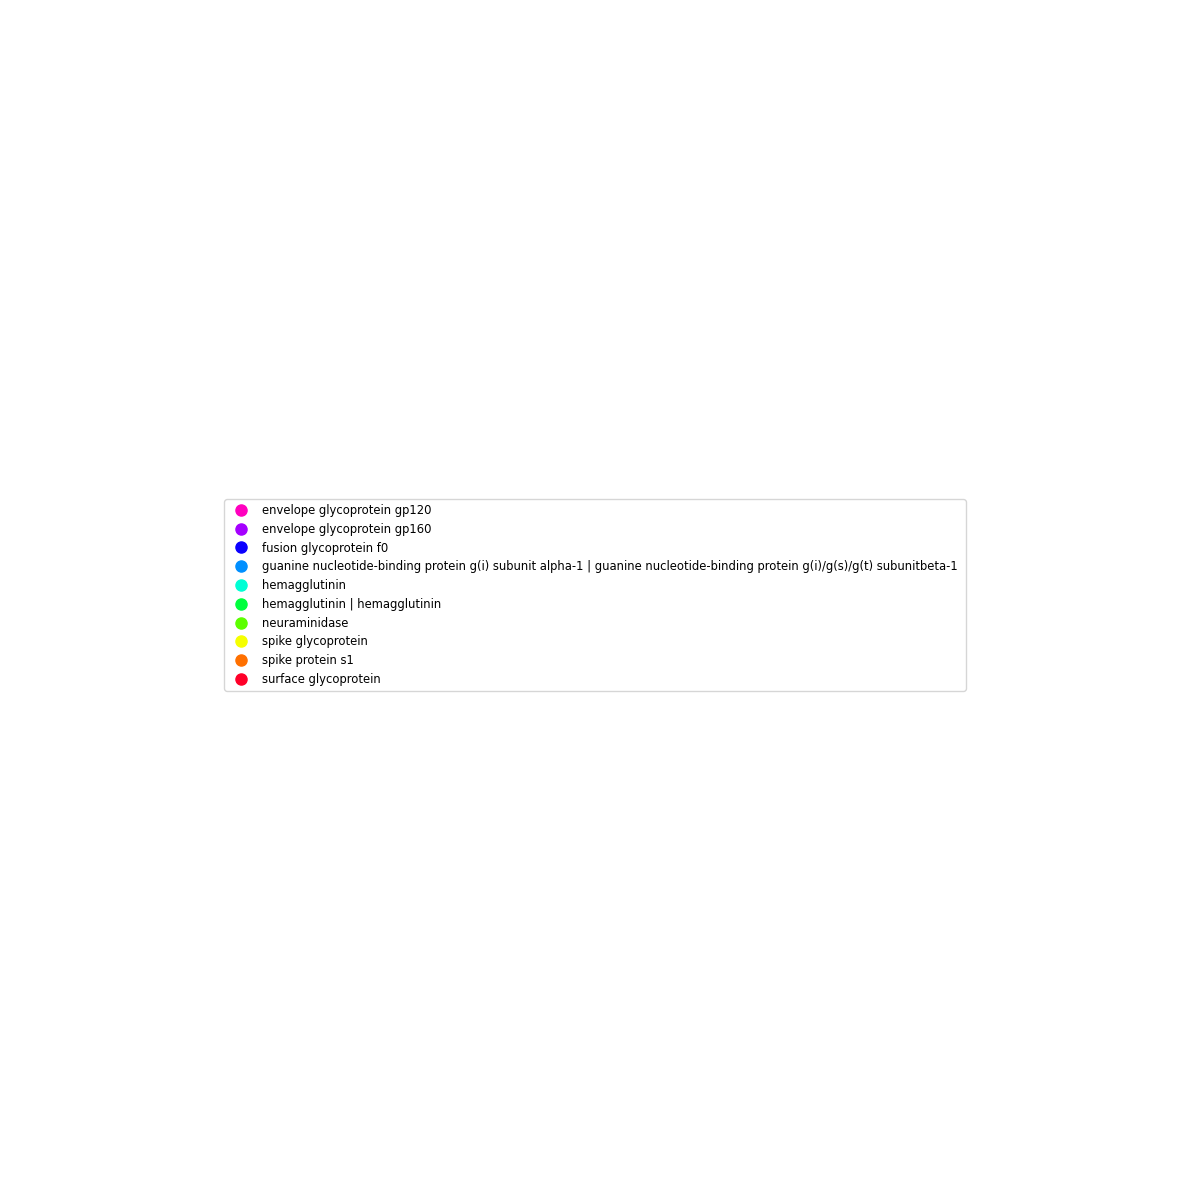

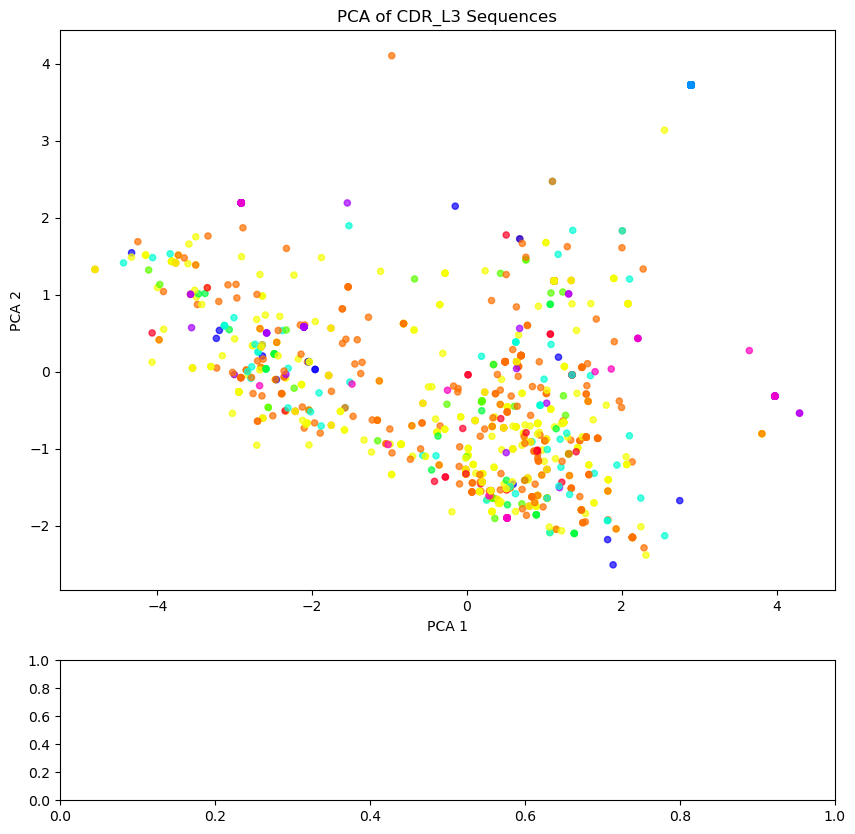

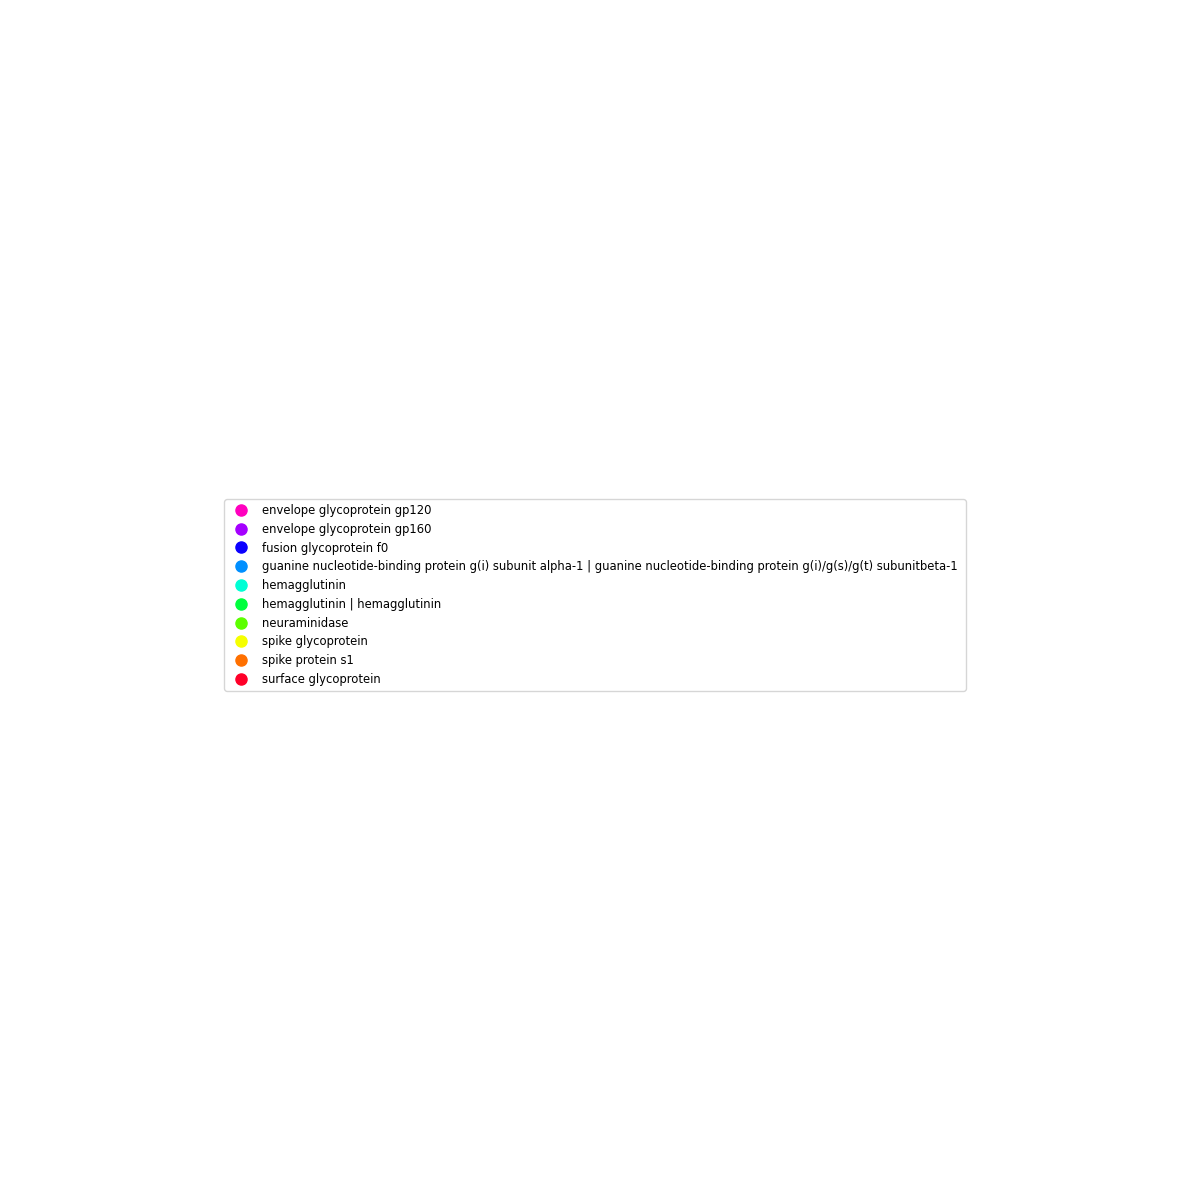

fusion glycoprotein f0: (0.04227053140096615, 0.0, 1.0, 1.0)
guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 : (0.0, 0.5615942028985507, 1.0, 1.0)
envelope glycoprotein gp160: (0.6461352657004832, 0.0, 1.0, 1.0)
surface glycoprotein: (1.0, 0.0, 0.16, 1.0)
spike protein s1: (1.0, 0.43843843843843866, 0.0, 1.0)
envelope glycoprotein gp120: (1.0, 0.0, 0.75, 1.0)
hemagglutinin | hemagglutinin: (0.0, 1.0, 0.23894862604540001, 1.0)
neuraminidase: (0.36036036036036045, 1.0, 0.0, 1.0)
spike glycoprotein: (0.9609609609609602, 1.0, 0.0, 1.0)
hemagglutinin: (0.0, 1.0, 0.836320191158901, 1.0)


In [7]:

for region in regions: 
    feature_space_visualize = feature_spaces[region].drop(columns=["antigen_name", "antigen_species"])
    show_feature_space(feature_space_visualize, region, antigen_labels)


#Überprüfung ob alle punkte mit gleichem antigen-name die gleiche farbe haben am bsp influenza a virus
idx_influenzaavirus = [i for i, a in enumerate(antigen_labels) if a == "influenza a virus"]
set([colors[i] for i in idx_influenzaavirus])

#alle farben pro antigen tabellarisch
for ant in set(antigen_labels):
    print(f"{ant}: {color_dict[ant]}")

c:\Users\chris\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Das System kann die angegebene Datei nicht finden
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\chris\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\chris\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\chris\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\chris\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.C

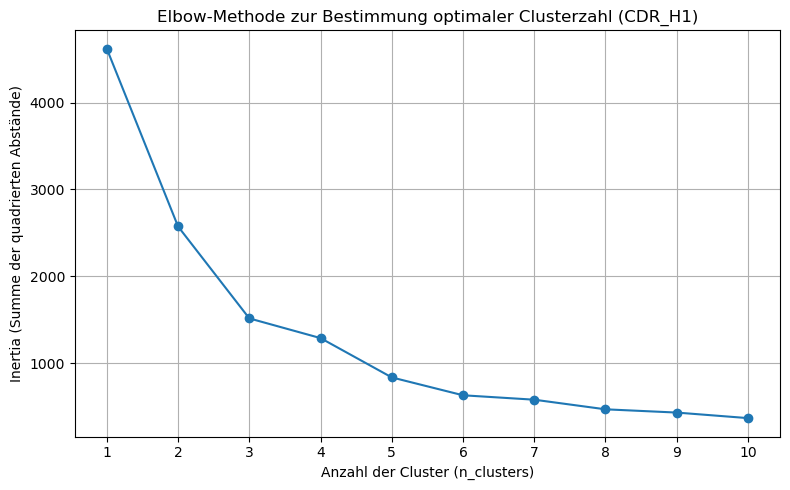

c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

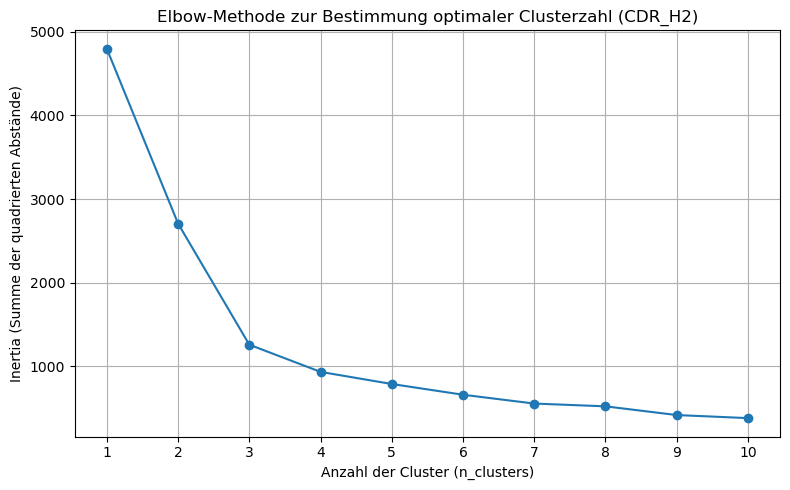

c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

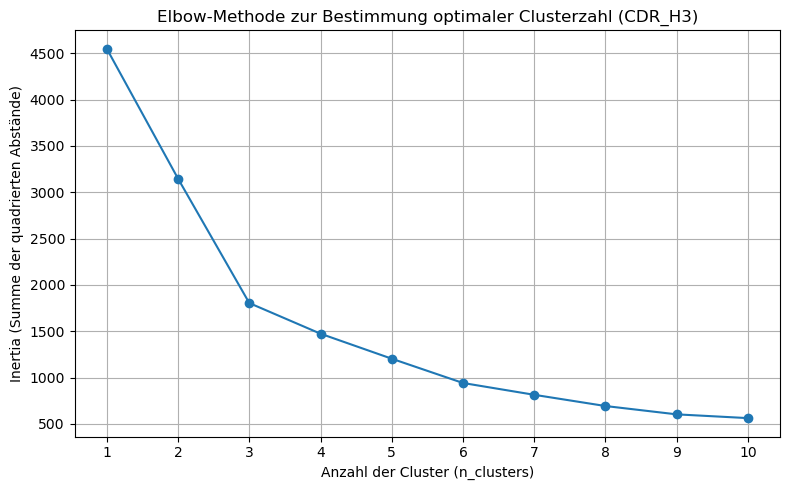

c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

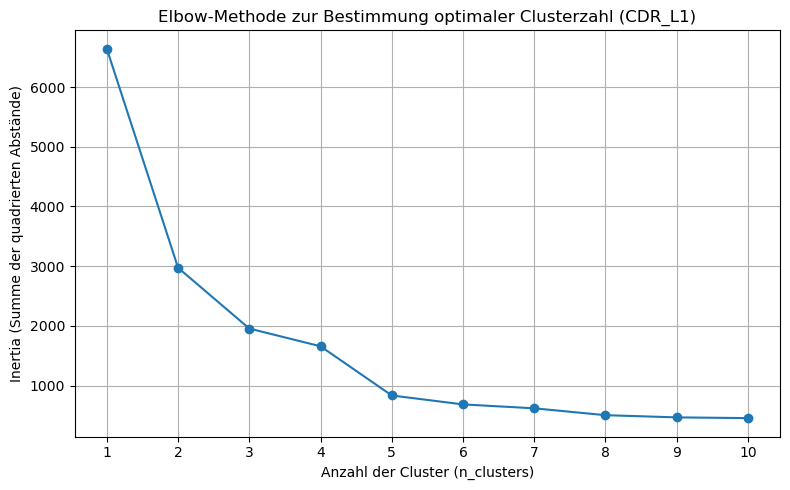

c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

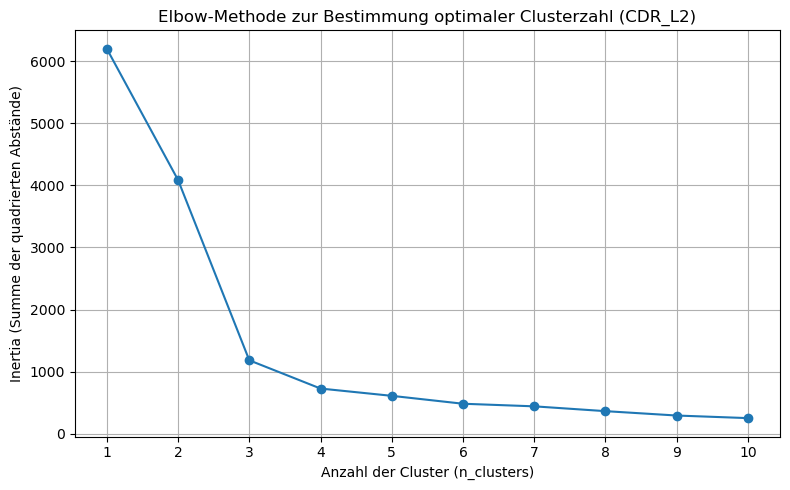

c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

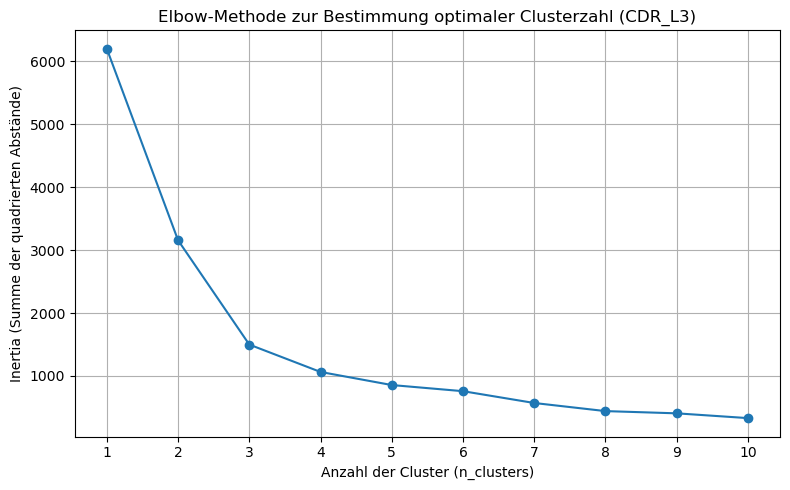

In [8]:
#elbow method 
#der erste teil ist wieder nur wdh weil der sonst die variabeln nicht findet

for region in regions:
    feature_space_elbow = feature_spaces[region].drop(columns=["antigen_name", "antigen_species"])

    #berücksichtigt nur top 10 aufgrund wie feature space definiert wurde
    X = feature_space_elbow.drop(columns=["pdb"])
    coords = PCA(n_components=2).fit_transform(X)

    #elbow method
    #inertia => Summe der quadrierten Abstände der Punkte zum jeweiligen Cluster-Zentrum => je kleiner, desto besser

    # Range of cluster numbers to try
    cluster_range = range(1, 11)  # Teste 1-10 Cluster

    # Hier Inertia-Werte speichern, [] für liste
    inertia_values = []

    # Berechne KMeans für jede Cluster-Anzahl
    for n_clusters in cluster_range:
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans.fit(coords)  # fit passt daten an modell an => kmeans bekommt daten (coords der antikörper punkte) und initialisiert Cluster Zentren und macht dann iterative optimierung 
        # also weist punkte dem nächsten cluster zentrum zu, bei den gebildeten cluster wenn neue zentren berechnet und die punkte werden neu zugeordnet
        inertia_values.append(kmeans.inertia_)

    # Plot der Elbow-Kurve
    plt.figure(figsize=(8, 5))
    plt.plot(cluster_range, inertia_values, marker='o')
    plt.xlabel('Anzahl der Cluster (n_clusters)')
    plt.ylabel('Inertia (Summe der quadrierten Abstände)')
    plt.title(f'Elbow-Methode zur Bestimmung optimaler Clusterzahl ({region})')
    plt.xticks(cluster_range) #x achse werden dann anzhal cluster gezeigt
    plt.grid(True) #gitternetzlinien im plot
    plt.tight_layout()
    plt.show()


c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


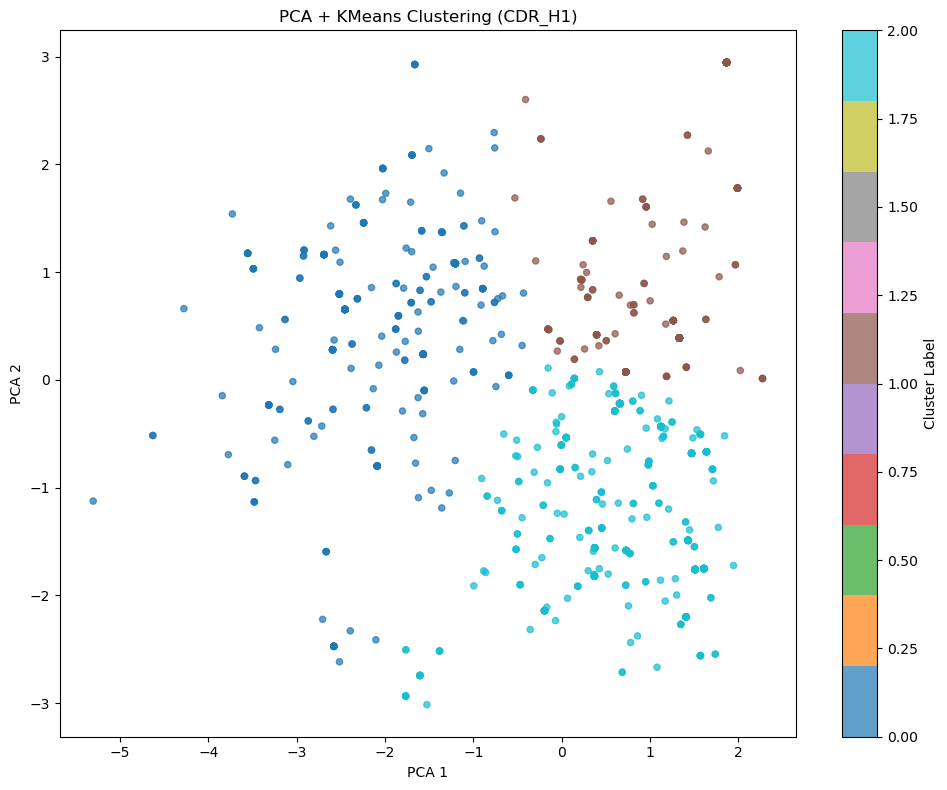


 Antigen Häufigkeiten pro Cluster für CDR_H1 

Cluster 0:
  spike protein s1: 116x
  spike glycoprotein: 83x
  hemagglutinin: 31x
  envelope glycoprotein gp160: 30x
  surface glycoprotein: 17x
  neuraminidase: 15x
  envelope glycoprotein gp120: 14x
  fusion glycoprotein f0: 4x
  hemagglutinin | hemagglutinin: 1x

Cluster 1:
  spike glycoprotein: 93x
  guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 : 77x
  spike protein s1: 77x
  hemagglutinin: 13x
  hemagglutinin | hemagglutinin: 10x
  fusion glycoprotein f0: 9x
  neuraminidase: 4x
  surface glycoprotein: 4x
  envelope glycoprotein gp160: 1x

Cluster 2:
  spike glycoprotein: 171x
  spike protein s1: 125x
  envelope glycoprotein gp120: 26x
  envelope glycoprotein gp160: 22x
  hemagglutinin: 20x
  neuraminidase: 16x
  hemagglutinin | hemagglutinin: 13x
  surface glycoprotein: 12x
  fusion glycoprotein f0: 8x


c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


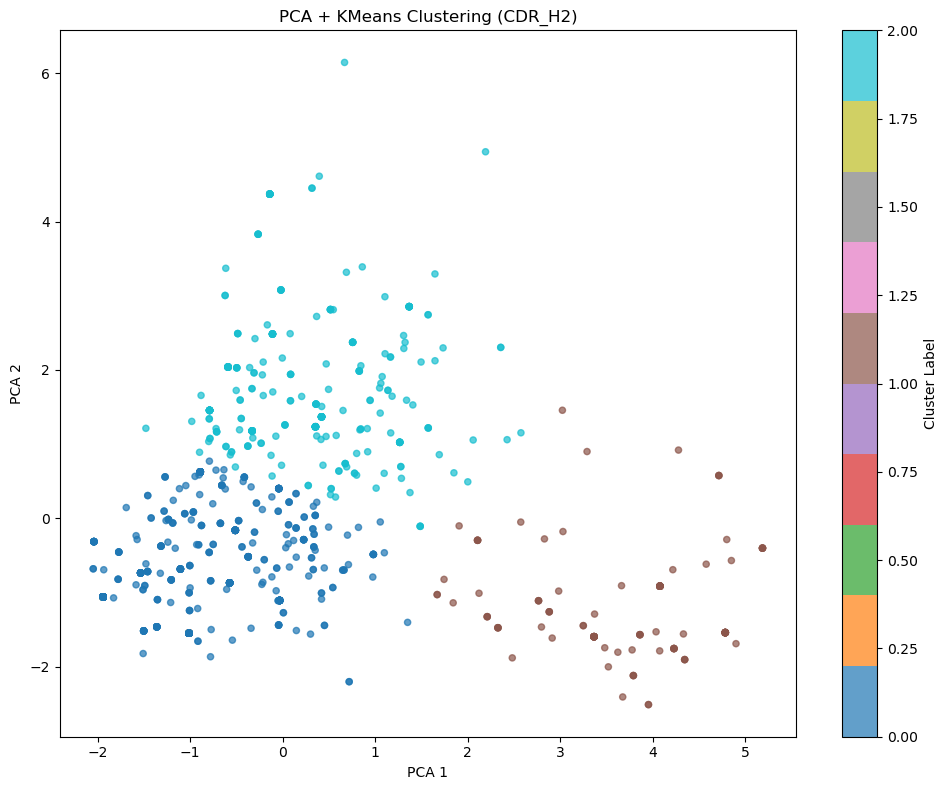


 Antigen Häufigkeiten pro Cluster für CDR_H2 

Cluster 0:
  spike protein s1: 216x
  spike glycoprotein: 193x
  guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 : 77x
  hemagglutinin: 37x
  surface glycoprotein: 27x
  fusion glycoprotein f0: 12x
  envelope glycoprotein gp160: 12x
  neuraminidase: 11x
  hemagglutinin | hemagglutinin: 10x
  envelope glycoprotein gp120: 4x

Cluster 1:
  spike glycoprotein: 45x
  spike protein s1: 23x
  neuraminidase: 15x
  envelope glycoprotein gp120: 15x
  hemagglutinin: 8x
  hemagglutinin | hemagglutinin: 8x
  envelope glycoprotein gp160: 6x
  fusion glycoprotein f0: 1x

Cluster 2:
  spike glycoprotein: 109x
  spike protein s1: 79x
  envelope glycoprotein gp160: 35x
  envelope glycoprotein gp120: 21x
  hemagglutinin: 19x
  neuraminidase: 9x
  fusion glycoprotein f0: 8x
  hemagglutinin | hemagglutinin: 6x
  surface glycoprotein: 6x


c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


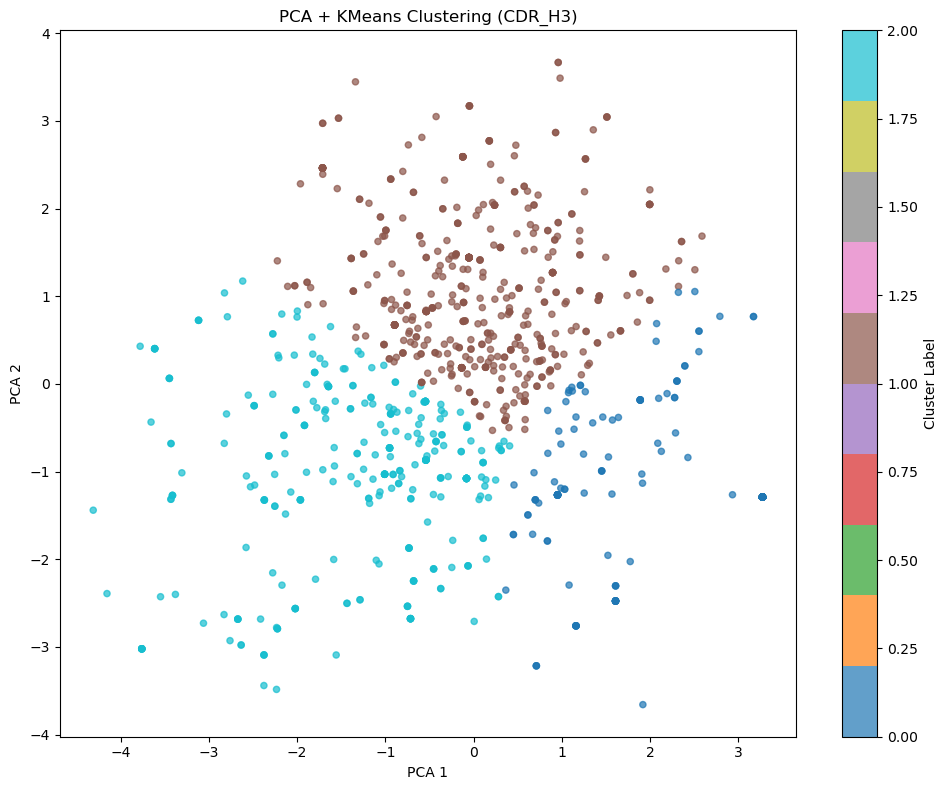


 Antigen Häufigkeiten pro Cluster für CDR_H3 

Cluster 0:
  guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 : 77x
  spike glycoprotein: 66x
  spike protein s1: 34x
  hemagglutinin: 6x
  surface glycoprotein: 5x
  hemagglutinin | hemagglutinin: 1x
  envelope glycoprotein gp160: 1x
  fusion glycoprotein f0: 1x

Cluster 1:
  spike glycoprotein: 155x
  spike protein s1: 149x
  envelope glycoprotein gp160: 50x
  hemagglutinin: 36x
  envelope glycoprotein gp120: 36x
  neuraminidase: 31x
  hemagglutinin | hemagglutinin: 16x
  surface glycoprotein: 15x
  fusion glycoprotein f0: 13x

Cluster 2:
  spike protein s1: 135x
  spike glycoprotein: 126x
  hemagglutinin: 22x
  surface glycoprotein: 13x
  hemagglutinin | hemagglutinin: 7x
  fusion glycoprotein f0: 7x
  neuraminidase: 4x
  envelope glycoprotein gp120: 4x
  envelope glycoprotein gp160: 2x


c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


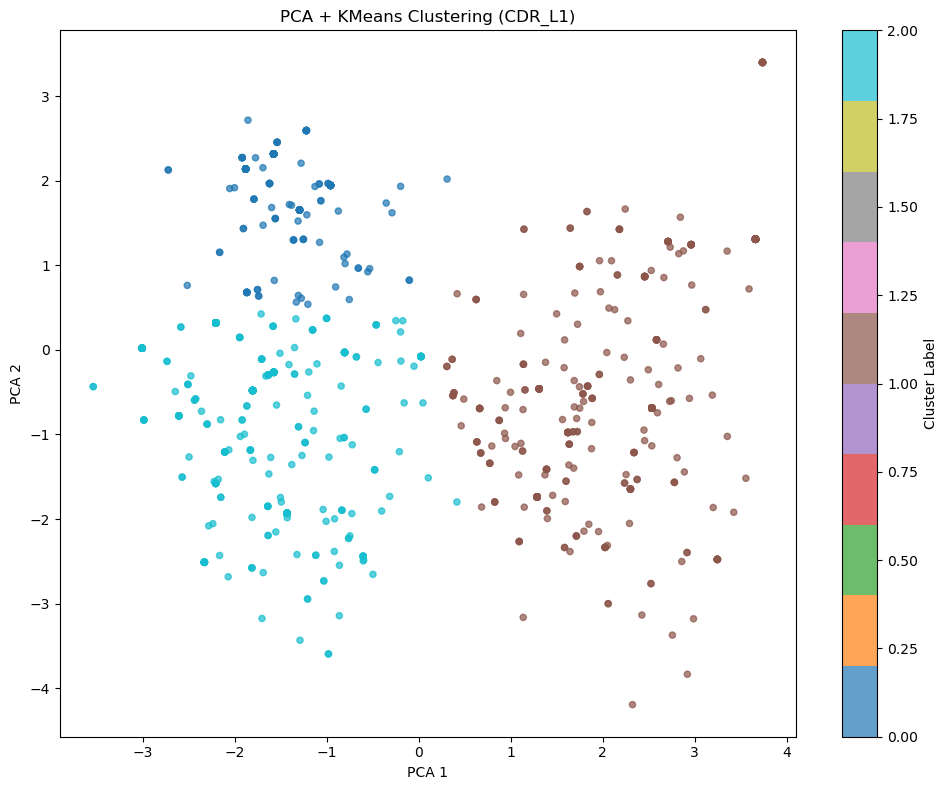


 Antigen Häufigkeiten pro Cluster für CDR_L1 

Cluster 0:
  spike glycoprotein: 85x
  spike protein s1: 72x
  neuraminidase: 15x
  envelope glycoprotein gp120: 15x
  surface glycoprotein: 13x
  hemagglutinin: 9x
  hemagglutinin | hemagglutinin: 5x
  envelope glycoprotein gp160: 2x

Cluster 1:
  spike glycoprotein: 129x
  spike protein s1: 109x
  guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 : 77x
  hemagglutinin: 30x
  envelope glycoprotein gp160: 22x
  fusion glycoprotein f0: 14x
  neuraminidase: 10x
  envelope glycoprotein gp120: 8x
  hemagglutinin | hemagglutinin: 8x
  surface glycoprotein: 6x

Cluster 2:
  spike protein s1: 137x
  spike glycoprotein: 133x
  envelope glycoprotein gp160: 29x
  hemagglutinin: 25x
  envelope glycoprotein gp120: 17x
  surface glycoprotein: 14x
  hemagglutinin | hemagglutinin: 11x
  neuraminidase: 10x
  fusion glycoprotein f0: 7x


c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


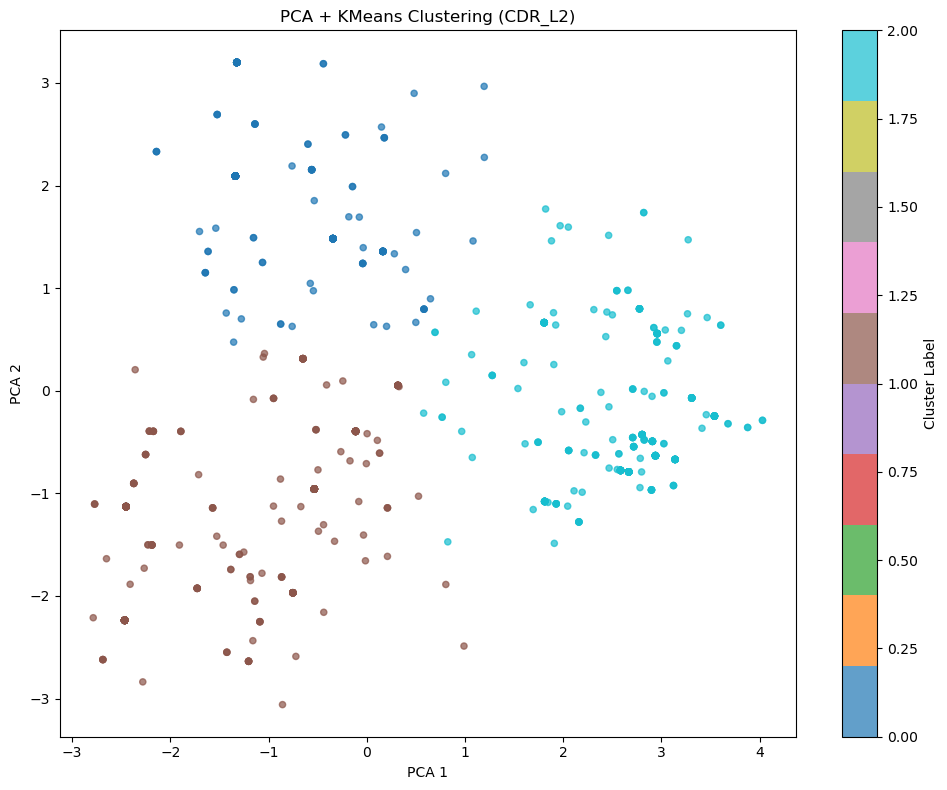


 Antigen Häufigkeiten pro Cluster für CDR_L2 

Cluster 0:
  spike glycoprotein: 106x
  spike protein s1: 92x
  envelope glycoprotein gp120: 21x
  neuraminidase: 15x
  surface glycoprotein: 15x
  envelope glycoprotein gp160: 15x
  hemagglutinin: 13x
  hemagglutinin | hemagglutinin: 6x
  fusion glycoprotein f0: 1x

Cluster 1:
  spike protein s1: 136x
  spike glycoprotein: 132x
  guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 : 77x
  hemagglutinin: 24x
  surface glycoprotein: 14x
  neuraminidase: 11x
  hemagglutinin | hemagglutinin: 10x
  fusion glycoprotein f0: 6x
  envelope glycoprotein gp160: 2x

Cluster 2:
  spike glycoprotein: 109x
  spike protein s1: 90x
  envelope glycoprotein gp160: 36x
  hemagglutinin: 27x
  envelope glycoprotein gp120: 19x
  fusion glycoprotein f0: 14x
  neuraminidase: 9x
  hemagglutinin | hemagglutinin: 8x
  surface glycoprotein: 4x


c:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


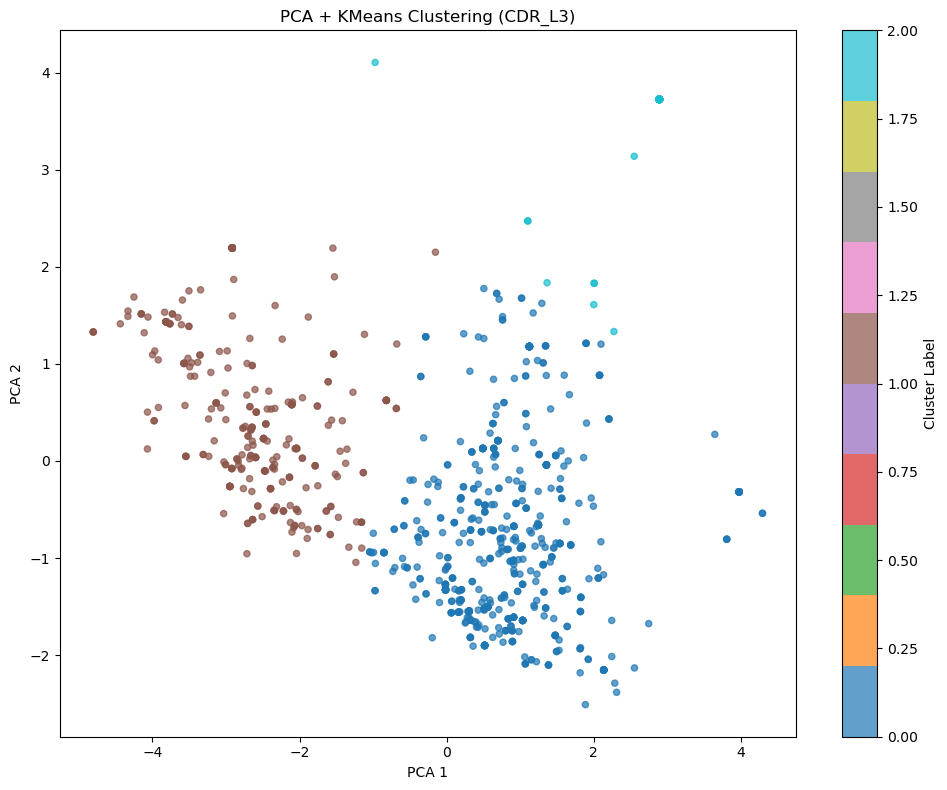


 Antigen Häufigkeiten pro Cluster für CDR_L3 

Cluster 0:
  spike glycoprotein: 239x
  spike protein s1: 226x
  hemagglutinin: 35x
  surface glycoprotein: 29x
  neuraminidase: 26x
  envelope glycoprotein gp120: 26x
  envelope glycoprotein gp160: 19x
  hemagglutinin | hemagglutinin: 16x
  fusion glycoprotein f0: 8x

Cluster 1:
  spike glycoprotein: 107x
  spike protein s1: 87x
  envelope glycoprotein gp160: 34x
  hemagglutinin: 26x
  envelope glycoprotein gp120: 14x
  fusion glycoprotein f0: 13x
  neuraminidase: 9x
  hemagglutinin | hemagglutinin: 8x
  surface glycoprotein: 4x

Cluster 2:
  guanine nucleotide-binding protein g(i) subunit alpha-1 | guanine nucleotide-binding protein g(i)/g(s)/g(t) subunitbeta-1 : 77x
  spike protein s1: 5x
  hemagglutinin: 3x
  spike glycoprotein: 1x


In [9]:
# Clustering auf basis der PCA
#kmeans mit 3 => laut elbow method am sinnvollsten

 # Schleife über die CDR-Regionen, um den Feature-Space für jede CDR-Sequenz zu erstellen:
for region in regions:
    feature_space_kmeans = feature_spaces[region].drop(columns=["antigen_name", "antigen_species"])
    
    #berücksichtigt nur top 10 aufgrund wie feature space definiert wurde
    X = feature_space_kmeans.drop(columns=["pdb"])
    coords = PCA(n_components=2).fit_transform(X)

    # n_clusters frei wählbar
    kmeans = KMeans(n_clusters=3, random_state=42) #random state wichtig damit auch bei jeden durchlauf gleiche cluster entstehen
    cluster_labels = kmeans.fit_predict(coords) #fit predict führt clustering im 2d pca space durch

    # Plot => Cluster einfärben
    plt.figure(figsize=(10, 8))
    plt.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, cmap='tab10', s=20, alpha=0.7) #c=cöuster labels färbt die punkte nach cluster; tab10 => 10 farben, alpha => tranparenz damit überlappungen sichtbar, s => punktgröße
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"PCA + KMeans Clustering ({region})")
    plt.colorbar(label='Cluster Label')
    plt.tight_layout()
    plt.show()

    #antigen names häufigkeiten in den clustern

    # Erzeuge Mapping: cluster_label → liste von antigen names
    # Dictionary ({} => speichert key => value paare) bauen, in dem für jedes Cluster die Liste der zugehörigen Antigen-Namen gespeichert wird
    cluster_antigen_mapping = {}

    # Gehe alle Punkte durch (alle Antikörper im PCA/Feature-Space)
    # → zip(cluster_labels, antigen_labels) gibt für jeden Punkt: cluster_label: die Cluster-Nummer (z.B. 0, 1, 2, ...) & antigen_name: der Antigen-Name dieses Antikörpers
    for cluster_label, antigen_name in zip(cluster_labels, antigen_labels):

        # Wenn dieses Cluster-Label noch nicht im Dictionary ist => leeres Array initialisieren
        if cluster_label not in cluster_antigen_mapping:
            cluster_antigen_mapping[cluster_label] = []

        # Füge den Antigen-Namen zur Liste für dieses Cluster hinzu
        cluster_antigen_mapping[cluster_label].append(antigen_name)

    #jetzt haben wir für jedes cluster eine liste mit den vorkommenden antigen names

    #für häufigkeiten:
    #header damit klar für welche cdr region
    print(f"\n Antigen Häufigkeiten pro Cluster für {region} ")
    # alle Cluster-Labels sortiert durchgehen
    for cluster_label in sorted(cluster_antigen_mapping.keys()):

        # Drucke Cluster-Header
        print(f"\nCluster {cluster_label}:")

        # wie oft jeder Antigen-Name in diesem Cluster vorkommt
        counter = Counter(cluster_antigen_mapping[cluster_label])

        # Antigen-Namen + Anzahl sortiert nach Häufigkeit aus geben
        for antigen, count in counter.most_common():
            print(f"  {antigen}: {count}x")


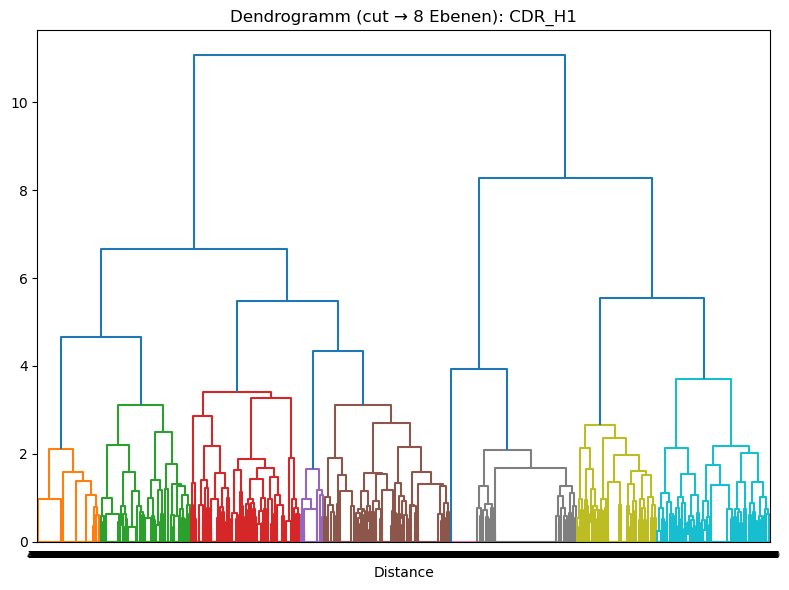


Teilbaum-Aufteilung für CDR_H1 (cut auf 8 Ebenen → 10 Teilbäume):

Teilbaum 1:
  spike glycoprotein: 50×
  spike protein s1: 22×
  unknown: 18×
  hemagglutinin | hemagglutinin: 10×
  interferon alpha-2: 10×
  ch848.10.17 gp120: 9×
  programmed cell death protein 1: 9×
  c-x-c chemokine receptor type 4: 8×
  complement factor d: 8×
  envelope glycoprotein b: 7×
  envelope glycoprotein h: 7×
  leukocyte surface antigen cd47: 7×
  b-lymphocyte antigen cd20: 6×
  gametocyte surface protein p230: 6×
  ch848.10.17.sosip gp120: 6×
  sars-cov-2 spike glycoprotein: 6×
  envelope glycoprotein gp120: 6×
  hemagglutinin ha1 chain: 5×
  envelope protein: 4×
  hemagglutinin ha1: 4×
  e2 glycoprotein: 4×
  rh5-34em: 4×
  envelope glycoprotein gp160: 4×
  envelope protein e: 4×
  nkg2-d type ii integral membrane protein: 4×
  envelope glycoprotein e: 4×
  germline-targeting hiv-1 gp120 engineered outer domain eod-gt8 : 4×
  butyrophilin subfamily 3 member a1: 4×
  spike glycoprotein e2: 4×
  ch848.3.

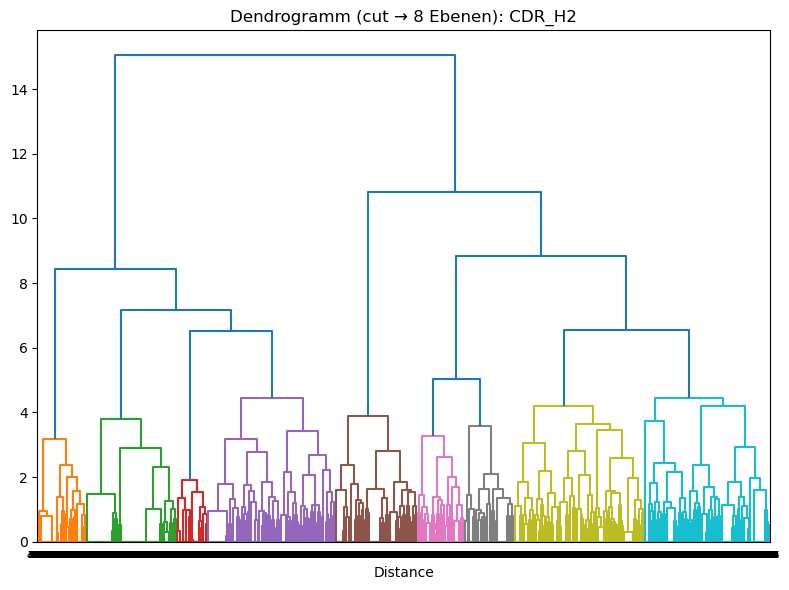


Teilbaum-Aufteilung für CDR_H2 (cut auf 8 Ebenen → 9 Teilbäume):

Teilbaum 1:
  epidermal growth factor receptor: 18×
  spike protein s1: 14×
  histone chaperone asf1: 12×
  spike glycoprotein: 12×
  vascular endothelial growth factor a: 11×
  hemagglutinin: 10×
  isoform l-vegf206 of vascular endothelial growth factor a: 7×
  envelope glycoprotein b: 6×
  antigen asf1p: 6×
  ephrin type-a receptor 2: 6×
  nucleoprotein: 6×
  neuraminidase: 6×
  tumor necrosis factor receptor superfamily member 9: 6×
  maltose-binding periplasmic protein: 5×
  erythropoietin receptor: 5×
  t-cell immunoreceptor with ig and itim domains: 4×
  receptor tyrosine-protein kinase erbb-2: 4×
  hemagglutinin ha2 chain | hemagglutinin ha1 chain: 4×
  glucagon receptor,endolysin,glucagon receptor: 4×
  immunoglobulin g binding protein a | protein l: 4×
  alpha-ketoglutarate-dependent dioxygenase alkb homolog 3: 4×
  interleukin-2: 4×
  surface glycoprotein: 4×
  atypical chemokine receptor 3: 4×
  protein-argin

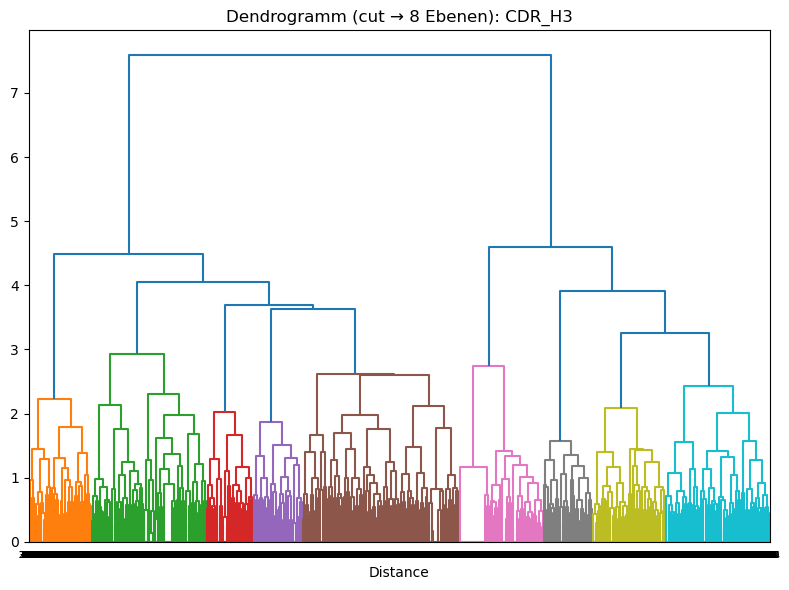


Teilbaum-Aufteilung für CDR_H3 (cut auf 8 Ebenen → 9 Teilbäume):

Teilbaum 1:
  spike glycoprotein: 49×
  spike protein s1: 29×
  programmed cell death protein 1: 12×
  surface glycoprotein: 11×
  envelope protein: 10×
  reticulocyte binding protein 2b: 8×
  neuraminidase: 8×
  interferon alpha-2: 8×
  fusion glycoprotein f0: 7×
  tyrosine-protein phosphatase non-receptor type substrate 1: 7×
  spike glycoprotein,fibritin: 7×
  unknown: 7×
  hemagglutinin: 7×
  circumsporozoite protein: 7×
  duffy binding surface protein region ii: 6×
  nsmgngc: 6×
  envelope glycoprotein e: 6×
  granulocyte-macrophage colony-stimulating factor: 6×
  envelope glycoprotein b: 6×
  core protein: 5×
  c-c motif chemokine 17: 4×
  e2 glycoprotein: 4×
  vascular endothelial growth factor a: 4×
  nkg2-d type ii integral membrane protein: 4×
  hepatitis a virus cellular receptor 2: 4×
  ALPHA-D-MANNOSE: 4×
  envelope glycoprotein gp120: 4×
  envelope protein e: 4×
  epidermal growth factor receptor: 4×
  pro

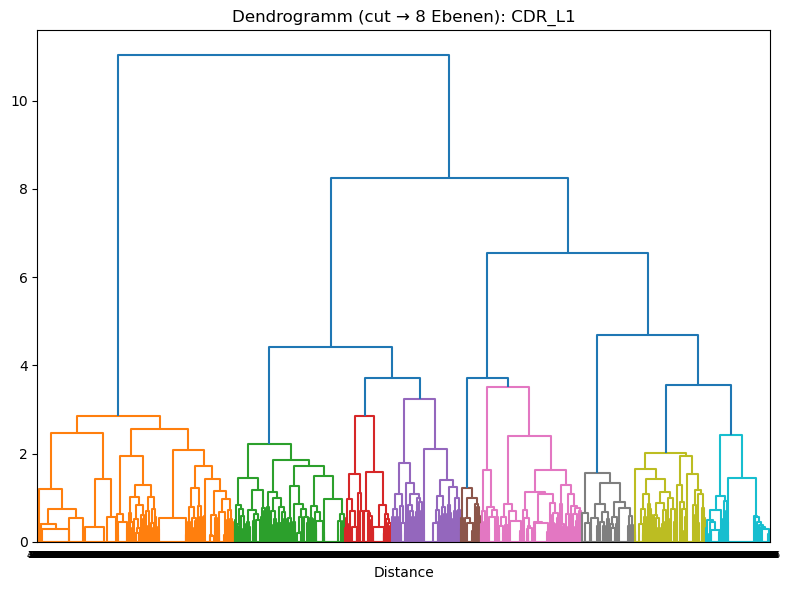


Teilbaum-Aufteilung für CDR_L1 (cut auf 8 Ebenen → 9 Teilbäume):

Teilbaum 1:
  spike glycoprotein: 223×
  spike protein s1: 127×
  neuraminidase: 44×
  circumsporozoite protein: 23×
  cobalt/magnesium transport protein cora | cobalt/magnesium transport protein cora: 23×
  surface glycoprotein: 22×
  hemagglutinin: 20×
  hemagglutinin ha2 chain | hemagglutinin ha1 chain: 17×
  envelope glycoprotein gp120: 17×
  gametocyte surface protein p230: 16×
  envelope glycoprotein e2: 15×
  programmed cell death protein 1: 15×
  spike protein s2': 13×
  epidermal growth factor receptor: 13×
  hemagglutinin | hemagglutinin: 13×
  histone chaperone asf1: 12×
  cadmium and zinc efflux pump fief: 12×
  vascular endothelial growth factor a: 10×
  interferon alpha-2: 10×
  spike glycoprotein | spike glycoprotein: 10×
  unknown: 9×
  exterior membrane glycoprotein(gp120): 8×
  triggering receptor expressed on myeloid cells 2: 8×
  cytotoxic t-lymphocyte protein 4: 7×
  spike glycoprotein,fibritin: 7×


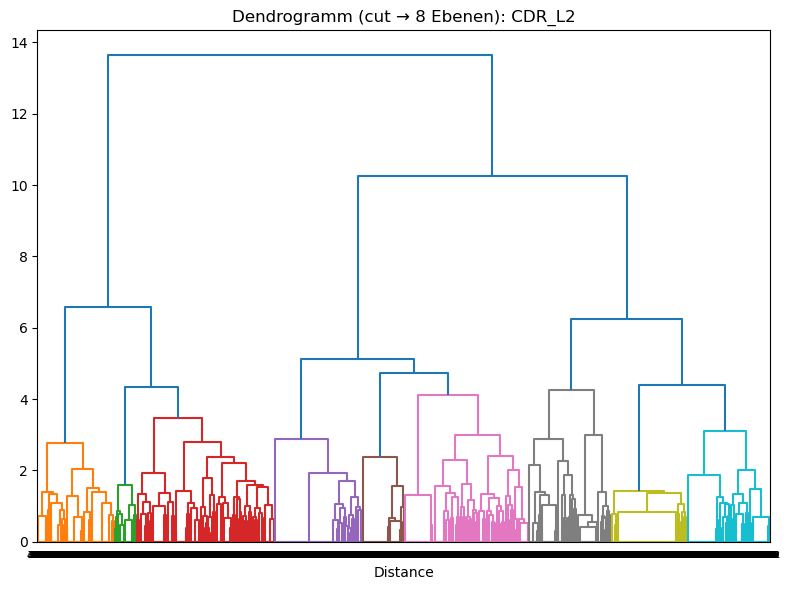


Teilbaum-Aufteilung für CDR_L2 (cut auf 8 Ebenen → 9 Teilbäume):

Teilbaum 1:
  spike glycoprotein: 72×
  spike protein s1: 33×
  hemagglutinin: 25×
  envelope glycoprotein gp160: 21×
  envelope glycoprotein gp120: 21×
  fusion glycoprotein f0: 20×
  hemagglutinin | hemagglutinin: 18×
  interleukin-17a: 16×
  envelope glycoprotein b: 14×
  circumsporozoite protein: 11×
  10e8 epitope scaffold t117v2: 9×
  plasmodium falciparum recombinant shortened csp: 9×
  tumor necrosis factor ligand superfamily member 13b: 7×
  e2 glycoprotein: 7×
  crf01_ae t/f100 hiv-1 gp120: 6×
  env glycoprotein gp160: 6×
  neuraminidase: 6×
  envelope protein: 6×
  lysozyme c: 5×
  receptor tyrosine-protein kinase erbb-3: 4×
  surface protein gp160: 4×
  c-x-c motif chemokine 13: 4×
  interleukin-9: 4×
  beta-nerve growth factor: 4×
  induced myeloid leukemia cell differentiation protein mcl-1 : 4×
  envelope glycoprotein: 4×
  frizzled-10: 4×
  crf-1_ae t/f100 env gp120: 3×
  envelope glycoprotein 1: 3×
  ig

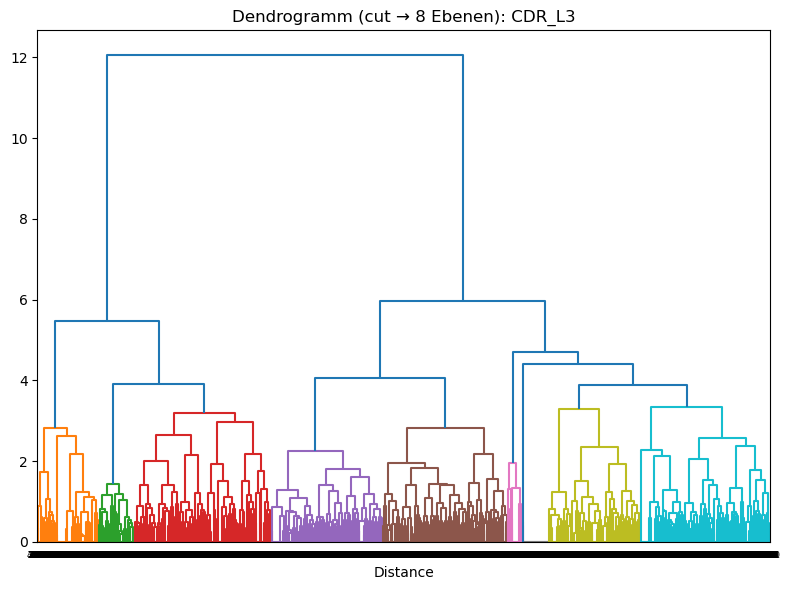


Teilbaum-Aufteilung für CDR_L3 (cut auf 8 Ebenen → 10 Teilbäume):

Teilbaum 1:
  spike protein s1: 55×
  spike glycoprotein: 47×
  envelope glycoprotein gp120: 23×
  cobalt/magnesium transport protein cora | cobalt/magnesium transport protein cora: 21×
  envelope glycoprotein gp160: 18×
  hemagglutinin: 17×
  fusion glycoprotein f0: 13×
  neuraminidase: 12×
  10e8 epitope scaffold t117v2: 9×
  hemagglutinin | hemagglutinin: 9×
  crf01_ae t/f100 hiv-1 gp120: 6×
  nucleoprotein: 6×
  envelope protein e: 6×
  lysozyme c: 5×
  erythropoietin receptor: 5×
  surface protein gp160: 4×
  interleukin-2: 4×
  envelope glycoprotein e: 4×
  envelope protein: 4×
  hyaluronan synthase 1: 3×
  core protein: 3×
  ubiquitin | ubiquitin d77: 3×
  spike glycoprotein,fibritin,expression tag: 3×
  proprotein convertase subtilisin/kexin type 9 | proprotein convertase subtilisin/kexin type 9: 3×
  rsv fusion glycoprotein: 3×
  sars-cov-2 spike glycoprotein: 3×
  crf-1_ae t/f100 env gp120: 3×
  e protein: 3×

In [10]:
# Hierarchisches Clustering und Identifikation der farbigen Teilbäume



# CDR-Spalten & Antigen-Spalte
cdr_columns = ['CDR_H1','CDR_H2','CDR_H3','CDR_L1','CDR_L2','CDR_L3']
antigen_col = "antigen_name"

# Wie viele Fusionen vom Wurzelknoten wir runterscrollen wollen
levels_down = 8   # z.B. 8 Ebenen

# Daten einlesen & unvollständige Zeilen entfernen
# zweite Zeile überflüssig, wenn Marcel data clean up korrekt gemacht hat
df = pd.read_csv("data/ab_ag_annotated.tsv", sep='\t')
df = df.dropna(subset=cdr_columns + [antigen_col]).reset_index(drop=True)


# AA-Häufigkeitsvektor-Funktion (20 Standard-AAs)
AA_LIST = list("ACDEFGHIKLMNPQRSTVWY")
def aa_freq_vector(seq: str) -> np.ndarray:   #aa_freq_vector name der Funktion, nimmt eine sequenz, die string sein soll, rückgabe ist np.ndarray (Vektor)
    L      = len(seq)                                                   # Sequenzlänge 
    counts = np.array([seq.count(aa) for aa in AA_LIST], dtype=float)   # Häufigkeit jeder AS
    return counts / L                                                    # direkte Normierung


#Loop über jede CDR-Region
for cdr in cdr_columns:
    seqs = df[cdr].tolist() #alle sequenzen als strings
    X    = np.vstack([aa_freq_vector(s) for s in seqs]) #für jede Sequenz 20 dimensionaler Häufigkeitsvektor, als Matrix zusammengeführt

    # Linkage berechnen (Ward, euklidische Distanz)
    Z = linkage(X, method="ward", metric="euclidean") #erstellt aus feature matrix X die linkage Matrix Z
                #ward minimiert varianz innerhalb der Cluster bei jedem merge

    # Threshold-Distanz für levels_down Stufen
    threshold = Z[-levels_down, 2] if levels_down <= Z.shape[0] else 0.0
            # Z.shape[0] ist Anzahl aller merge schritte (n-1 für sequenzen)
            # Z[-levels_down,2] Distanz des Merge_schrittes der Plätze von unten


    # Erzeuge das Dendrogramm im "no_plot"-Modus, um Farben der Blätter abzufragen
    ddata = dendrogram(
        Z,
        labels=[str(i) for i in range(len(seqs))],
        color_threshold=threshold,
        no_plot=True       # unterdrückt die Grafik, liefert aber in ddata alle nötigen Infos
    )

    # Verbindet Blatt indizes mit Farbe
    leaves           = ddata['leaves']            # Reihenfolge der Blatt-Indizes
    leaves_colors    = ddata['leaves_color_list'] # RGB-Farben pro Blatt, gemäß threshold
    leaf_color_map   = {leaf: col for leaf, col in zip(leaves, leaves_colors)}
                    # zip leaves verbindet blatt_indizes mit jeweiliger Farbe
                    # leaf: baut ein dict, indem der Blatt_index(leaves) und das entsprechende RGB-Farb-Tuple (col) ist

    

    #Hier nochmal genau den Code nachvollziehen
    # 10) Finde die eindeutigen Farben in der Reihenfolge ihres Auftretens
    unique_colors = [] #ist Liste aller verschieder RGB-Farben, die in Dendrogramm auftauchen
    for col in leaves_colors:
        if col not in unique_colors:
            unique_colors.append(col) #Lister aller verschiedenen Farben, wie sie auftauchen, in gleicher Reihenfolge

    


    #  Weise jeder Farbe eine Cluster-Nummer zu
    color_cluster_map = {col: idx+1 for idx, col in enumerate(unique_colors)}
   
    # 12) Cluster-Zuordnung für jedes Blatt nach Farbe
    cluster_ids = {leaf: color_cluster_map[col] for leaf, col in leaf_color_map.items()}

    # 13) Plot des vollständigen Dendrogramms mit Farb-Schwellenwert
    plt.figure(figsize=(8, 6))
    dendrogram(
        Z,
        labels=[str(i) for i in range(len(seqs))],
        color_threshold=threshold,  # färbt die Haupt-Branches
        leaf_rotation=0,
        leaf_font_size=6
    )
    plt.title(f"Dendrogramm (cut → {levels_down} Ebenen): {cdr}")
    plt.xlabel("Distance")
    plt.tight_layout()
    plt.show()

    # 14) Ausgabe: für jeden farbigen Teilbaum die Antigen-Häufigkeiten
    print(f"\nTeilbaum-Aufteilung für {cdr} (cut auf {levels_down} Ebenen → {len(unique_colors)} Teilbäume):")
    for col in unique_colors:
        cid     = color_cluster_map[col]
        # alle Blätter, deren Farbe = col
        leaves_in_cluster = [leaf for leaf, c in leaf_color_map.items() if c == col]
        # Antigen-Namen der entsprechenden Zeilen
        hits    = df.loc[leaves_in_cluster, antigen_col]
        counts  = hits.value_counts()
        print(f"\nTeilbaum {cid}:")
        for antigen, cnt in counts.items():
            print(f"  {antigen}: {cnt}×")


In [11]:

#Proportionstest => testen, ob die Antigen-Namen systematisch unterschiedlich auf die Cluster verteilt sind

#nullhypothese (H0): Verteilung der Antigen-Namen auf die Cluster ist zufällig
#H1: Verteilung der Antigen-Namen auf die Cluster ist nicht zufällig

for region in regions:

    # Kontingenztabelle (Antigen x Cluster) erzeugen

    # automatische Zählung und erstellen von dataframe über crosstab
    contingency_table = pd.crosstab(pd.Series(antigen_labels, name='Antigen'), pd.Series(cluster_labels, name='Cluster'))

    #kontingenztabelle printen
    print(f"\n Kontingenztabelle für {region}")
    print(contingency_table)

    #chi-quadrat-test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    #chi2=maß für wie stark die beobachteten häufigkeiten von den erwarteten abweichen (je größer, desto größer abweichung)
    #p-Wert=Wahrscheinlichkeit, bei zufälliger Verteilung eine Abweichung mindestens so groß wie chi2 zu beobachten
    #dof=degrees of freedom (#zeilen-1 * #spalten-1)
    #expected=tabelle mit erwarteten häufigkeiten unter nullhypothese

    #print ergebnisse
    print(f"\n Chi-Quadrat-Test Ergebnis für {region}")
    print(f"Chi2-Wert: {chi2:.4f}") #4f für 4 nachkommSTELLEN
    print(f"p-Wert:    {p:.4e}")  # 4e für exponentielle darstellung mit 4 nachkommastellen
    print(f"Freiheitsgrade: {dof}")

    #print die expected werte zum vergleich
    expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
    print(f"\nErwartete Häufigkeiten (unter Nullhypothese):")
    print(expected_df.round(2)) #auf 2 nachkommastellen runden

    #die tatsache dass die antigen_name häufigkeiten sehr unterschiedlich sind wird hier automatisch berücksichtigt: 
    #expected-Array wird aus den Randhäufigkeiten berechnet => randhäufigkeiten für antigen =  Summe pro Zeile => wie oft kommt jedes Antigen insgesamt im ganzen Datensatz vor?
    #randhäufigkeiten für cluster=Summe pro Spalte => wie groß ist jedes Cluster insgesamt?

    #wenn p < 0.05 => signifikant also die verteilung unterschiedet sich signifikant von zufall => N0 hypothese muss verworfen werden denn die unterschiede in der verteilung sind nicht durch zufall zu erklären



 Kontingenztabelle für CDR_H1
Cluster                                               0    1   2
Antigen                                                         
envelope glycoprotein gp120                          26   14   0
envelope glycoprotein gp160                          19   34   0
fusion glycoprotein f0                                8   13   0
guanine nucleotide-binding protein g(i) subunit...    0    0  77
hemagglutinin                                        35   26   3
hemagglutinin | hemagglutinin                        16    8   0
neuraminidase                                        26    9   0
spike glycoprotein                                  239  107   1
spike protein s1                                    226   87   5
surface glycoprotein                                 29    4   0

 Chi-Quadrat-Test Ergebnis für CDR_H1
Chi2-Wert: 949.0685
p-Wert:    5.3014e-190
Freiheitsgrade: 18

Erwartete Häufigkeiten (unter Nullhypothese):
Cluster                                  